# **Program 1: Write a program to implement 3D Hyperplane in SVM.**

In [1]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import mglearn
from sklearn.datasets import make_blobs

In [3]:
# Generate sample data
X, Y = make_blobs(centers=2, random_state=8)
Y = Y % 2

In [5]:
# Train linear SVM
from sklearn.svm import LinearSVC
linear_svm = LinearSVC()
linear_svm.fit(X, Y)

# Add a 3rd feature (square of second feature)
X_new = np.hstack([X, (X[:, 1] ** 2).reshape(-1, 1)])

# Train new 3D SVM
linear_svm_3d = LinearSVC()
linear_svm_3d.fit(X_new, Y)

# Extract coefficients
coef, intercept = linear_svm_3d.coef_.ravel(), linear_svm_3d.intercept_

[False False False  True False  True False False False False  True  True
  True False False  True  True False False  True  True  True  True  True
  True False False False  True False  True False False  True False False
  True False False False False False  True  True  True  True  True  True
 False  True  True False False  True False False  True False  True False
  True False  True  True False  True  True  True  True False  True  True
  True  True False False False  True False  True False False False False
  True False False  True  True False False False  True  True False  True
  True False  True  True]


C:\Users\Joy Santra\AppData\Local\Temp\ipykernel_20088\360514132.py:17: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b', cmap=mglearn.cm2, s=60)
C:\Users\Joy Santra\AppData\Local\Temp\ipykernel_20088\360514132.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', cmap=mglearn.cm2, s=60)


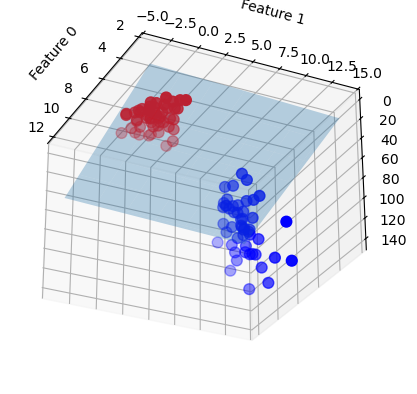

In [6]:
# Plotting 3D hyperplane
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d', elev=152, azim=26)

xx = np.linspace(X_new[:, 0].min() - 2, X_new[:, 0].max() + 2, 50)
yy = np.linspace(X_new[:, 1].min() - 2, X_new[:, 1].max() + 2, 50)
XX, YY = np.meshgrid(xx, yy)
ZZ = (-coef[0] * XX - coef[1] * YY - intercept) / coef[2]

# Plot surface
ax.plot_surface(XX, YY, ZZ, rstride=8, cstride=8, alpha=0.3)

# Separate classes for plotting
mask = Y == 0
print(mask)

ax.scatter(X_new[mask, 0], X_new[mask, 1], X_new[mask, 2], c='b', cmap=mglearn.cm2, s=60)
ax.scatter(X_new[~mask, 0], X_new[~mask, 1], X_new[~mask, 2], c='r', cmap=mglearn.cm2, s=60)

ax.set_xlabel("Feature 0")
ax.set_ylabel("Feature 1")
ax.set_zlabel("Feature 1 ** 2")

plt.show()